In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train,y_train), (X_test,y_test) = datasets.cifar10.load_data()

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
X_train.shape

(50000, 32, 32, 3)

In [6]:
y_train.shape

(50000, 1)

In [7]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [8]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [9]:
y_test = y_test.reshape(-1,)

In [10]:
classes = ['airplane','automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [11]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

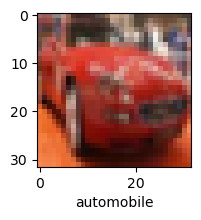

In [12]:
plot_sample(X_train, y_train, 5)

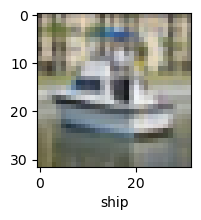

In [13]:
plot_sample(X_train,y_train,501)

In [14]:
X_train = X_train /255.0
X_test = X_test / 255.0

In [15]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32,32,3)),
    layers.Dense(3000,activation = 'relu'),
    layers.Dense(1000,activation = 'relu'),
    layers.Dense(10,activation = 'softmax')

])

ann.compile(optimizer = 'SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train,y_train, epochs=5)


C:\Users\jingy\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.3543 - loss: 1.8123
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.4277 - loss: 1.6218
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.4559 - loss: 1.5419
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4785 - loss: 1.4820
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4955 - loss: 1.4315


In [16]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification report:\n', classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
classification report:
               precision    recall  f1-score   support

           0       0.58      0.56      0.57      1000
           1       0.51      0.72      0.60      1000
           2       0.36      0.38      0.37      1000
           3       0.40      0.22      0.29      1000
           4       0.50      0.31      0.38      1000
           5       0.45      0.32      0.38      1000
           6       0.47      0.62      0.53      1000
           7       0.45      0.68      0.54      1000
           8       0.69      0.53      0.60      1000
           9       0.55      0.58      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



In [17]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

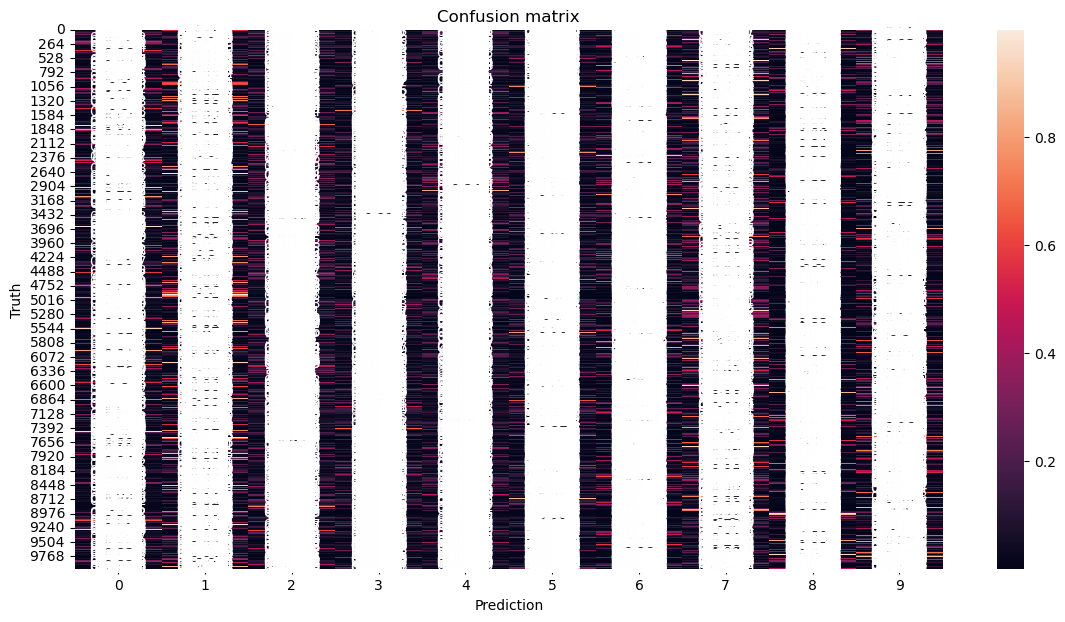

In [18]:
plt.figure(figsize = (14,7))
sns.heatmap(y_pred,annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix')
plt.show

In [19]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\jingy\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn.compile(optimizer='adam',
             loss = 'sparse_categorical_crossentropy', 
             metrics= ['accuracy'])

In [21]:
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.4607 - loss: 1.4943
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.5950 - loss: 1.1447
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6390 - loss: 1.0300
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6675 - loss: 0.9538
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.6882 - loss: 0.8945
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7027 - loss: 0.8471
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.7182 - loss: 0.8053
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7330 - loss: 0.7672
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7418 - loss: 0.7364
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7530 - loss: 0.7040


In [22]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6877 - loss: 0.9181


[0.9181010723114014, 0.6876999735832214]

In [23]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[2.05817603e-04, 4.34549851e-03, 2.90144328e-03, 8.43339324e-01,
        2.47908058e-04, 1.32422699e-02, 2.33753268e-02, 5.97051658e-05,
        1.12054095e-01, 2.28578821e-04],
       [3.13343853e-02, 3.19212139e-01, 4.04843968e-06, 1.90222991e-07,
        3.24198132e-04, 5.91570490e-08, 1.33156899e-08, 1.55732914e-06,
        6.18898273e-01, 3.02252285e-02],
       [4.68268022e-02, 2.35883355e-01, 3.83177469e-03, 1.58489812e-02,
        8.20171926e-03, 1.74055097e-03, 5.88879397e-04, 1.47208676e-03,
        6.57345772e-01, 2.82600541e-02],
       [8.83358121e-01, 3.22599662e-03, 3.80131579e-03, 4.21520206e-04,
        2.50398181e-03, 7.73826905e-05, 1.57022558e-04, 5.05823482e-05,
        1.06248252e-01, 1.55978414e-04],
       [1.28568263e-06, 1.21851786e-04, 1.20682875e-02, 3.04492395e-02,
        8.19229782e-01, 8.15498736e-03, 1.29944488e-01, 5.20782442e-06,
        2.17977267e-05, 3.14016165e-06]], dtype=float32)

In [24]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 4]

In [25]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

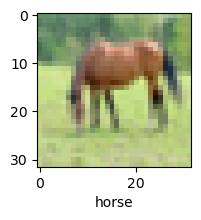

In [26]:
plot_sample(X_test,y_test,60)

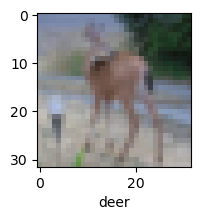

In [27]:
plot_sample(X_test,y_test, 100)

In [28]:
classes[y_classes[60]]

'horse'